# 03 — Train the sliding-window classifier

This is the from-scratch detector: a small CNN that classifies a single 64x64 crop as "Waldo" or
"not Waldo", turned into a full-scene detector by sliding it across the image at several scales,
batching the crops through the network, thresholding the resulting confidence map, and collapsing
overlapping detections with non-max suppression. Every one of those steps (IoU, NMS, the sliding-window
loop itself) is implemented in `src/eval/box_utils.py` and `src/models/sliding_window.py` — nothing here
comes from a detection framework.

Plan:
1. Train on one fold in detail, inspect loss curves and a qualitative full-scene detection.
2. Run the same training + full-scene evaluation across all 5 folds, since a single 3-4 scene
   validation set (notebook 02) is too small to trust on its own.
3. Hard-negative mining: bootstrap a second round of training data from the model's own false
   positives, and check whether it actually helps.
4. Save the final model for notebook 05 (evaluation/error analysis) and the demo app.

In [1]:
import ast
import sys
from pathlib import Path

PROJECT_ROOT = Path.cwd().parent

sys.path.insert(0, str(PROJECT_ROOT))

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch
from PIL import Image

from src.data.patch_generation import PATCH_SIZE
from src.eval.metrics import match_detections, mean_localization_error, precision_recall
from src.models.patch_classifier import PatchClassifier
from src.models.sliding_window import detect
from src.models.train_utils import DEFAULT_DEVICE, train_fold

PROCESSED_DIR = PROJECT_ROOT / "data" / "processed"
MODELS_DIR = PROJECT_ROOT / "models"
MODELS_DIR.mkdir(exist_ok=True)
plt.rcParams["figure.dpi"] = 110
torch.manual_seed(0)

print(f"Training device: {DEFAULT_DEVICE}")
IOU_THRESHOLD = 0.3  # used throughout this notebook to decide if a predicted box "counts" as a match

# Retrained on the expanded corpus (notebook 02, Part 2): original generated
# patches + ~3,100 Hey-Waldo human-curated patches, since the honest result
# further down used to be near-zero precision from too little patch diversity.
patch_manifest = pd.read_csv(PROCESSED_DIR / "patch_manifest_expanded.csv")
patch_manifest["scene_id"] = patch_manifest["scene_id"].astype(str)
fold_assignment = pd.read_csv(PROCESSED_DIR / "fold_assignment.csv")
fold_assignment["scene_id"] = fold_assignment["scene_id"].astype(str)

scenes = pd.read_csv(PROCESSED_DIR / "clean_manifest.csv")
scenes["boxes"] = scenes["boxes"].apply(ast.literal_eval)
scenes["scene_id"] = scenes["scene_id"].astype(str)

N_FOLDS = fold_assignment["val_fold"].nunique()
print(f"{len(patch_manifest)} patches, {len(scenes)} scenes, {N_FOLDS} folds")


Training device: cpu
3982 patches, 19 scenes, 5 folds


## Model

`PatchClassifier` (`src/models/patch_classifier.py`) is a small 4-block CNN with batchnorm, dropout, and
global average pooling instead of a large flatten+FC head — kept small on purpose, since a few thousand
patches cut from only 19 source scenes will overfit a large network almost immediately.

In [2]:
model = PatchClassifier()
n_params = sum(p.numel() for p in model.parameters())
print(model)
print(f"\n{n_params:,} trainable parameters")

PatchClassifier(
  (features): Sequential(
    (0): Sequential(
      (0): Conv2d(3, 16, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(16, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (1): Sequential(
      (0): Conv2d(16, 32, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(32, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False)
    )
    (2): Sequential(
      (0): Conv2d(32, 64, kernel_size=(3, 3), stride=(1, 1), padding=(1, 1))
      (1): BatchNorm2d(64, eps=1e-05, momentum=0.1, affine=True, bias=True, track_running_stats=True)
      (2): ReLU(inplace=True)
      (3): MaxPool2d(kernel_size=2, stride=2, padding=0, dilation=1, ceil_mode=False

## Train fold 0 in detail

The training loop (`src/models/train_utils.py`) weights the loss by class frequency
(`pos_weight = n_negative / n_positive`), since even the *undersampled* patch corpus is heavily skewed
(3,760 negative vs 222 positive patches, about 17:1) — without this, the optimizer has an easy shortcut
(predict "negative" always) that plain unweighted BCE loss wouldn't sufficiently penalize.

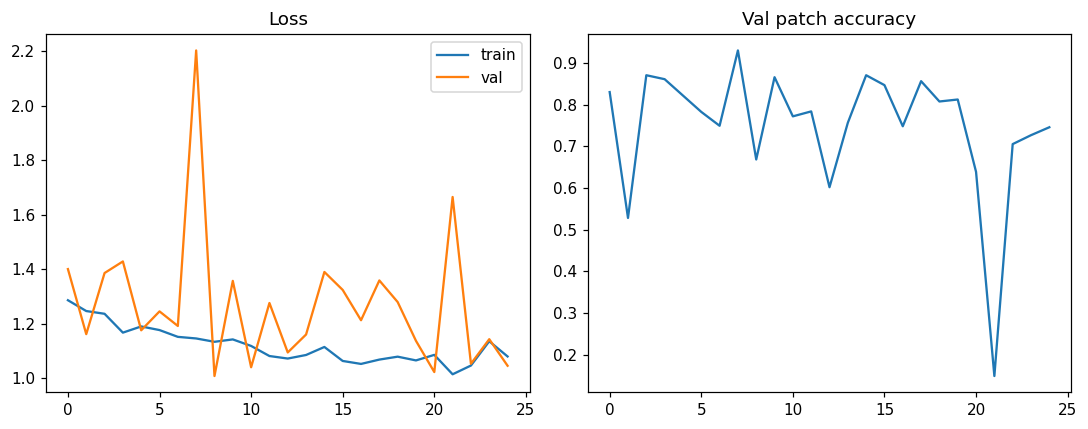

In [3]:
model_fold0 = PatchClassifier()
history_fold0 = train_fold(model_fold0, patch_manifest, fold_assignment, val_fold=0, epochs=25)

fig, axes = plt.subplots(1, 2, figsize=(10, 4))
axes[0].plot(history_fold0.train_loss, label="train")
axes[0].plot(history_fold0.val_loss, label="val")
axes[0].set_title("Loss")
axes[0].legend()
axes[1].plot(history_fold0.val_accuracy)
axes[1].set_title("Val patch accuracy")
plt.tight_layout()
plt.show()

## Choosing an operating threshold

`detect()` needs a confidence threshold to decide which windows count as "Waldo" before NMS. Rather than
picking one arbitrarily, sweep it on fold 0's validation scenes and look at the actual precision/recall
trade-off — this also doubles as a first real check of whether the model discriminates Waldo from
background at all across a *full scene* (very different from patch-level validation accuracy, which only
ever sees pre-cropped, roughly-centered examples).

In [4]:
fold0_val_scenes = scenes.merge(fold_assignment, on="scene_id").query("val_fold == 0")

threshold_sweep = []
for thresh in [0.5, 0.6, 0.7, 0.8, 0.9, 0.95, 0.98, 0.99]:
    matches = []
    for _, scene in fold0_val_scenes.iterrows():
        image = Image.open(scene["image_path"])
        dets = detect(model_fold0, image, score_threshold=thresh, nms_iou_threshold=0.2)
        matches.append(match_detections([d.box for d in dets], scene["boxes"], iou_threshold=IOU_THRESHOLD))
    p, r = precision_recall(matches)
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    tp = sum(m.true_positives for m in matches)
    fp = sum(m.false_positives for m in matches)
    threshold_sweep.append({"threshold": thresh, "precision": p, "recall": r, "f1": f1, "tp": tp, "fp": fp})

sweep_df = pd.DataFrame(threshold_sweep)
SCORE_THRESHOLD = float(sweep_df.loc[sweep_df["f1"].idxmax(), "threshold"])
print(f"Best F1 at threshold={SCORE_THRESHOLD}")
sweep_df

Best F1 at threshold=0.6


,threshold,precision,recall,f1,tp,fp
0,0.50,0.002426,1.00,0.004840,4,1645
1,0.60,0.002602,0.75,0.005186,3,1150
2,0.70,0.001957,0.25,0.003883,1,510
3,0.80,0.000000,0.00,0.000000,0,71
4,0.90,0.000000,0.00,0.000000,0,0
5,0.95,0.000000,0.00,0.000000,0,0
6,0.98,0.000000,0.00,0.000000,0,0
7,0.99,0.000000,0.00,0.000000,0,0


**Reading the sweep.** On fold 0's validation scenes the model *does* respond to Waldo: at threshold 0.6 it
finds 3 of the 4 Waldo boxes (recall 0.75) — but with ~1,150 false positives across those 4 scenes
(precision 0.003). Raising the threshold doesn't isolate him: at 0.7 recall is already down to 0.25 with
~500 false positives still left, and from 0.8 up the model detects nothing at all. Scores for real Waldo
windows and for background windows overlap almost completely, so no cutoff gives a usable
precision/recall trade-off.

`SCORE_THRESHOLD` (the best-F1 row, 0.6) is used for the rest of this notebook so the operating point is
at least principled rather than arbitrary — but it doesn't change the picture. (It is tuned on fold 0
only and then applied to all five folds.) The most likely cause — a hypothesis; this notebook doesn't
isolate it — is the mismatch between what the classifier was trained on (clean, roughly-centered crops)
and what a sliding window actually feeds it (thousands of arbitrary, mostly off-target crops), on top of
very few real positive examples.

## Qualitative check: full-scene sliding-window detection

Patch accuracy tells us almost nothing about whether this model can actually *find* Waldo in a full,
unseen scene — that's a different task (localization, not just classification of a pre-cropped patch).
Run it on one of fold 0's held-out scenes and look.

Scene 1: 358 detections after NMS (threshold=0.6)


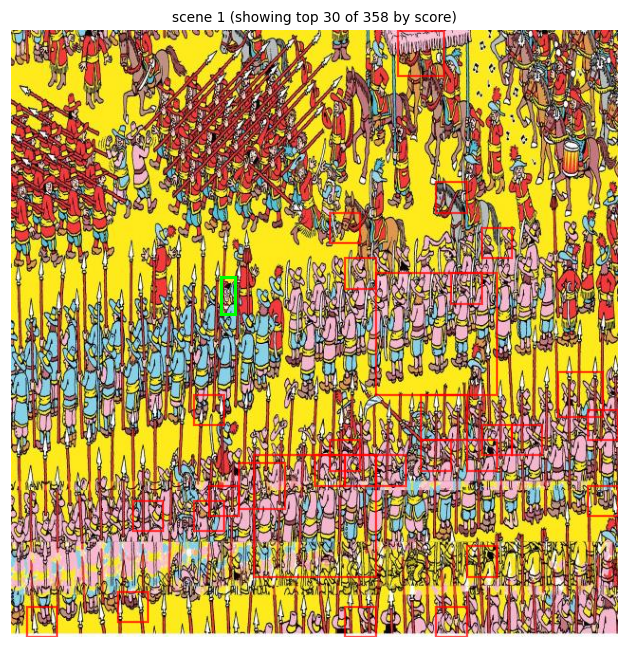

In [5]:
def show_detections(image: Image.Image, dets, gt_boxes, title: str, ax=None, max_boxes_to_draw: int = 30):
    own_fig = ax is None
    if own_fig:
        fig, ax = plt.subplots(figsize=(6, 6))
    ax.imshow(image)
    for box in gt_boxes:
        x1, y1, x2, y2 = box
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="lime", linewidth=2, label="ground truth"))
    shown = sorted(dets, key=lambda d: d.score, reverse=True)[:max_boxes_to_draw]
    for det in shown:
        x1, y1, x2, y2 = det.box
        ax.add_patch(plt.Rectangle((x1, y1), x2 - x1, y2 - y1, fill=False, edgecolor="red", linewidth=1.5, alpha=0.7))
    if len(dets) > max_boxes_to_draw:
        title += f" (showing top {max_boxes_to_draw} of {len(dets)} by score)"
    ax.set_title(title, fontsize=9)
    ax.axis("off")
    if own_fig:
        plt.tight_layout()
        plt.show()


sample_scene = fold0_val_scenes.iloc[0]
sample_image = Image.open(sample_scene["image_path"])

dets = detect(model_fold0, sample_image, score_threshold=SCORE_THRESHOLD, nms_iou_threshold=0.2)
print(f"Scene {sample_scene['scene_id']}: {len(dets)} detections after NMS (threshold={SCORE_THRESHOLD})")
show_detections(sample_image, dets, sample_scene["boxes"], f"scene {sample_scene['scene_id']}")

## Full cross-validation

Train fresh on each of the 5 folds, run full-scene sliding-window detection on every scene in that
fold's validation split, and match predicted boxes to ground truth with `match_detections` (from
`src/eval/metrics.py`) at IoU >= 0.3. Aggregating precision/recall across all 19 scenes (each evaluated
exactly once, from whichever fold held it out) gives a far more trustworthy read than any single fold's
3-4 scene validation set.

In [6]:
fold_models = {0: model_fold0}
all_matches = []
per_scene_results = []

for fold in range(N_FOLDS):
    if fold == 0:
        fold_model = model_fold0
    else:
        fold_model = PatchClassifier()
        train_fold(fold_model, patch_manifest, fold_assignment, val_fold=fold, epochs=15)
        fold_models[fold] = fold_model

    val_scenes = scenes.merge(fold_assignment, on="scene_id").query("val_fold == @fold")
    for _, scene in val_scenes.iterrows():
        image = Image.open(scene["image_path"])
        dets = detect(fold_model, image, score_threshold=SCORE_THRESHOLD, nms_iou_threshold=0.2)
        pred_boxes = [d.box for d in dets]
        match = match_detections(pred_boxes, scene["boxes"], iou_threshold=IOU_THRESHOLD)
        all_matches.append(match)
        per_scene_results.append(
            {
                "scene_id": scene["scene_id"],
                "fold": fold,
                "tp": match.true_positives,
                "fp": match.false_positives,
                "fn": match.false_negatives,
            }
        )
    print(f"fold {fold} done")

precision, recall = precision_recall(all_matches)
mle = mean_localization_error(all_matches)
print(f"\nAcross all {len(scenes)} scenes (IoU>={IOU_THRESHOLD}, score_threshold={SCORE_THRESHOLD}):")
print(f"  Precision: {precision:.3f}")
print(f"  Recall:    {recall:.3f}")
print(f"  Mean localization error (matched detections): {mle:.1f}px" if mle else "  No true positives")

pd.DataFrame(per_scene_results)

fold 0 done


fold 1 done


fold 2 done


fold 3 done


fold 4 done

Across all 19 scenes (IoU>=0.3, score_threshold=0.6):
  Precision: 0.002
  Recall:    0.381
  Mean localization error (matched detections): 10.1px


,scene_id,fold,tp,fp,fn
0,1,0,1,357,0
1,2,0,0,286,1
2,6,0,1,204,0
3,12,0,1,303,0
4,4,1,0,135,1
5,9,1,1,378,0
6,14,1,0,104,1
7,17,1,1,208,1
8,3,2,0,104,1
9,10,2,1,70,1


In [7]:
results_out = pd.DataFrame(per_scene_results)
results_out.to_csv(PROCESSED_DIR / "sliding_window_cv_results.csv", index=False)
sweep_df.to_csv(PROCESSED_DIR / "sliding_window_threshold_sweep.csv", index=False)
print(f"Saved CV results and threshold sweep to {PROCESSED_DIR}")

Saved CV results and threshold sweep to D:\python_envs\wheres-wally\data\processed


## Hard-negative mining

The negatives in `data/processed/patches/` are *easy*: uniformly random crops. A classifier can reach
decent accuracy on those while still firing on genuinely confusable background clutter (striped
textures, faces of other characters) that it never saw as a hard example during training. Standard fix,
used since the earliest sliding-window detectors (Viola-Jones, HOG+SVM): run the current model over the
**training** scenes only (never validation — that would leak the evaluation set into training), collect
windows it confidently but wrongly calls "Waldo", and add those as new negative training examples for a
second training round.

We demonstrate this on fold 0 and compare precision/recall on fold 0's validation scenes before vs.
after, rather than re-running it for all 5 folds (the mechanism generalizes; running it 5x would just
cost more compute for the same demonstration).

In [8]:
from src.data.patch_generation import Patch
from src.eval.box_utils import iou as box_iou


def mine_hard_negatives(model, train_scenes: pd.DataFrame, max_per_scene: int = 15, score_threshold: float = SCORE_THRESHOLD):
    hard_negatives = []
    for _, scene in train_scenes.iterrows():
        image = Image.open(scene["image_path"])
        dets = detect(model, image, score_threshold=score_threshold, nms_iou_threshold=0.3)
        gt = [np.array(b) for b in scene["boxes"]]

        false_positives = [
            d for d in dets if not gt or max(box_iou(np.array(d.box), g) for g in gt) < 0.1
        ]
        false_positives.sort(key=lambda d: d.score, reverse=True)

        for det in false_positives[:max_per_scene]:
            crop = image.crop(det.box).resize((PATCH_SIZE, PATCH_SIZE), Image.BILINEAR)
            hard_negatives.append(Patch(image=np.array(crop.convert("RGB")), label=0, scene_id=scene["scene_id"], source_box=None))
    return hard_negatives


fold0_train_scenes = scenes.merge(fold_assignment, on="scene_id").query("val_fold != 0")
hard_negatives = mine_hard_negatives(model_fold0, fold0_train_scenes)
print(f"Mined {len(hard_negatives)} hard-negative windows from {len(fold0_train_scenes)} training scenes (threshold={SCORE_THRESHOLD})")

Mined 225 hard-negative windows from 15 training scenes (threshold=0.6)


In [9]:
HARD_NEG_DIR = PROCESSED_DIR / "patches" / "hard_negative"
HARD_NEG_DIR.mkdir(parents=True, exist_ok=True)

hard_neg_rows = []
for i, patch in enumerate(hard_negatives):
    path = HARD_NEG_DIR / f"{patch.scene_id}_hardneg_{i:03d}.png"
    Image.fromarray(patch.image).save(path)
    hard_neg_rows.append({"scene_id": patch.scene_id, "label": 0, "path": str(path)})

augmented_manifest = pd.concat([patch_manifest, pd.DataFrame(hard_neg_rows)], ignore_index=True)

model_fold0_v2 = PatchClassifier()
train_fold(model_fold0_v2, augmented_manifest, fold_assignment, val_fold=0, epochs=25)

def evaluate_on_fold(model, fold: int):
    val_scenes = scenes.merge(fold_assignment, on="scene_id").query("val_fold == @fold")
    matches = []
    for _, scene in val_scenes.iterrows():
        image = Image.open(scene["image_path"])
        dets = detect(model, image, score_threshold=SCORE_THRESHOLD, nms_iou_threshold=0.2)
        matches.append(match_detections([d.box for d in dets], scene["boxes"], iou_threshold=IOU_THRESHOLD))
    return precision_recall(matches)

p0, r0 = evaluate_on_fold(model_fold0, 0)
p1, r1 = evaluate_on_fold(model_fold0_v2, 0)
print(f"Fold 0 before hard-negative mining: precision={p0:.3f}, recall={r0:.3f}")
print(f"Fold 0 after hard-negative mining:  precision={p1:.3f}, recall={r1:.3f}")

Fold 0 before hard-negative mining: precision=0.003, recall=0.750
Fold 0 after hard-negative mining:  precision=0.002, recall=0.750


**Hard-negative mining did not help.** 225 hard negatives were mined from the 15 training scenes and the
model retrained: on fold 0's validation scenes recall stayed at 0.75 and precision went from 0.003 to
0.002 — no meaningful change. (In an earlier pass on the smaller 886-patch corpus, before the Hey-Waldo
patches were added, the same step had made recall collapse; with the expanded corpus it simply doesn't
move the needle.) The fold-0 model from *before* mining is kept as the saved model: it's no worse, and
there's no evidence mining helps here. Reported as found, rather than re-running with hand-tuned caps
until a flattering number appears.

## Save the model

Save `model_fold0` (before hard-negative mining, which showed no benefit) as the stage-1 model that
notebook 05 and the demo app load. It's trained on 15 of the 19 scenes (fold 0's train split) — not ideal
for a "final" deployed model (we'd normally retrain on all data once the setup is chosen via
cross-validation), but it keeps this notebook's numbers directly traceable to the fold-0 evaluation above.
Weights are saved as CPU tensors so they load on any machine.

In [10]:
cpu_state = {k: v.cpu() for k, v in model_fold0.state_dict().items()}  # loadable on CPU-only machines
torch.save(cpu_state, MODELS_DIR / "sliding_window_classifier.pt")
print(f"Saved to {MODELS_DIR / 'sliding_window_classifier.pt'}")

Saved to D:\python_envs\wheres-wally\models\sliding_window_classifier.pt


## Takeaways → what this motivates for notebook 04

- The from-scratch pipeline runs end to end: patch classifier → multi-scale sliding window → NMS →
  full-scene detections, scored with IoU-based precision/recall rather than accuracy. Every mechanic (IoU,
  NMS, the window loop) is hand-implemented and inspectable.
- **Result (5-fold cross-validation over all 19 scenes, 3,982-patch corpus, threshold 0.6):** 8 of the 21
  Waldo boxes are found (recall 0.38, mean localization error 10.1 px) — but with 4,203 false positives
  (precision 0.002, about 220 false boxes per scene). Waldo is *found* in 8 of 19 scenes but buried among
  hundreds of other boxes, so as a "point at Waldo" tool this is not usable.
- **The extra data helped recall, not precision.** In the first pass (886 patches, before adding
  Hey-Waldo's) recall was about 0.05 at essentially the same precision; the larger, more varied patch
  corpus raised recall roughly sevenfold but did nothing for the false-positive flood.
- **Hard-negative mining made no meaningful difference** (fold 0: precision 0.003 → 0.002, recall 0.75 →
  0.75).
- This is the "from scratch, fully understood" half of the baseline-vs-modern comparison. Practical cost,
  also worth carrying forward: exhaustive multi-scale sliding-window inference is thousands of forward
  passes per image, so it's far slower than a detector that scores the whole image once — timed in
  notebook 04.